In [2]:
%pip install  -e . 

Obtaining file:///Users/rolandmitric/MASTER_PROGRAMMING_2026/live_notebooks
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for theochem_live (pyproject.toml) ... done
  Created wheel for theochem_live: filename=theochem_live-0.1.0-0.editable-py3-none-any.whl size=2776 sha256=76ea4485c6ed93dc38588f5cb3925cbb0ca31089e5c83b9808497f72c3665332
  Stored in directory: /private/var/folders/cp/hbk0qs4x4ggb5z_vv2hkmcgw0000gn/T/pip-ephem-wheel-cache-4k5ajk3b/wheels/a8/61/bd/318087ecc54d7e0ca7146aa39c26758304348afc27f0ad3eb7
Successfully built theochem_live
  Attempting uninstall: theochem_live
    Found existing installation: theochem_live 0.1.0
    Uninstalling theochem_live-0.1.0:
      Successfully uninstalled theochem_live-0.1.0

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: 

In [3]:
from src_live import Molecule, BasisSet, ELEMENT_SYMBOL, Shell, S, T, V 

In [4]:
benzene_xyz = """12
Benzene molecule
C 0.000000 1.402720 0.000000
C 1.214790 0.701360 0.000000
C 1.214790 -0.701360 0.000000
C 0.000000 -1.402720 0.000000
C -1.214790 -0.701360 0.000000
C -1.214790 0.701360 0.000000
H 0.000000 2.490290 0.000000
H 2.156660 1.245150 0.000000
H 2.156660 -1.245150 0.000000
H 0.000000 -2.490290 0.000000
H -2.156660 -1.245150 0.000000
H -2.156660 1.245150 0.000000
"""

In [5]:
benzene = Molecule.from_string(benzene_xyz)
sto3g = BasisSet("sto-3g")
sto3g.download_from_bse(["C", "H"])
print(sto3g)

Dump data to sto-3g.json
Basis set: sto-3g
Element: H
l = 0, exponents = [3.42525091 0.62391373 0.1688554 ], coefficients = [0.15432897 0.53532814 0.44463454]
Element: C
l = 0, exponents = [71.61683735 13.04509632  3.53051216], coefficients = [0.15432897 0.53532814 0.44463454]
l = 0, exponents = [2.94124936 0.6834831  0.22228992], coefficients = [-0.09996723  0.39951283  0.70011547]
l = 1, exponents = [2.94124936 0.6834831  0.22228992], coefficients = [0.15591627 0.60768372 0.39195739]



In [6]:
from pprint import pformat
Lmax = 2
def l_to_ijk(L):
    IJK = []
    for I in range(L, -1, -1):
        for J in range(L - I, -1, -1):
            IJK.append((I, J, L - I - J))
    return sorted(IJK, reverse = True)

LA_LB_TO_IJKLMN = {}
for la in range(Lmax + 1):
    for lb in range(Lmax +1):
        LA_LB_TO_IJKLMN[(la, lb)] = [ijk + lmn for ijk in l_to_ijk(la) for lmn in l_to_ijk(lb)]

print(f"LA_LB_TO_IJKLMN = {pformat(LA_LB_TO_IJKLMN, sort_dicts = False)}")

LA_LB_TO_IJKLMN = {(0, 0): [(0, 0, 0, 0, 0, 0)],
 (0, 1): [(0, 0, 0, 1, 0, 0), (0, 0, 0, 0, 1, 0), (0, 0, 0, 0, 0, 1)],
 (0, 2): [(0, 0, 0, 2, 0, 0),
          (0, 0, 0, 1, 1, 0),
          (0, 0, 0, 1, 0, 1),
          (0, 0, 0, 0, 2, 0),
          (0, 0, 0, 0, 1, 1),
          (0, 0, 0, 0, 0, 2)],
 (1, 0): [(1, 0, 0, 0, 0, 0), (0, 1, 0, 0, 0, 0), (0, 0, 1, 0, 0, 0)],
 (1, 1): [(1, 0, 0, 1, 0, 0),
          (1, 0, 0, 0, 1, 0),
          (1, 0, 0, 0, 0, 1),
          (0, 1, 0, 1, 0, 0),
          (0, 1, 0, 0, 1, 0),
          (0, 1, 0, 0, 0, 1),
          (0, 0, 1, 1, 0, 0),
          (0, 0, 1, 0, 1, 0),
          (0, 0, 1, 0, 0, 1)],
 (1, 2): [(1, 0, 0, 2, 0, 0),
          (1, 0, 0, 1, 1, 0),
          (1, 0, 0, 1, 0, 1),
          (1, 0, 0, 0, 2, 0),
          (1, 0, 0, 0, 1, 1),
          (1, 0, 0, 0, 0, 2),
          (0, 1, 0, 2, 0, 0),
          (0, 1, 0, 1, 1, 0),
          (0, 1, 0, 1, 0, 1),
          (0, 1, 0, 0, 2, 0),
          (0, 1, 0, 0, 1, 1),
          (0, 1, 0, 0, 0, 2

In [7]:
from dataclasses import dataclass, field
import copy
import numpy as np
from numba import njit
from numba.typed import List

ANG2BOHR = 1.8897259886
DIM_SHELL = {0: 1, 1: 3, 2: 6, 3: 10}
LA_LB_TO_IJKLMN = {(0, 0): [(0, 0, 0, 0, 0, 0)],
 (0, 1): [(0, 0, 0, 1, 0, 0), (0, 0, 0, 0, 1, 0), (0, 0, 0, 0, 0, 1)],
 (0, 2): [(0, 0, 0, 2, 0, 0),
          (0, 0, 0, 1, 1, 0),
          (0, 0, 0, 1, 0, 1),
          (0, 0, 0, 0, 2, 0),
          (0, 0, 0, 0, 1, 1),
          (0, 0, 0, 0, 0, 2)],
 (1, 0): [(1, 0, 0, 0, 0, 0), (0, 1, 0, 0, 0, 0), (0, 0, 1, 0, 0, 0)],
 (1, 1): [(1, 0, 0, 1, 0, 0),
          (1, 0, 0, 0, 1, 0),
          (1, 0, 0, 0, 0, 1),
          (0, 1, 0, 1, 0, 0),
          (0, 1, 0, 0, 1, 0),
          (0, 1, 0, 0, 0, 1),
          (0, 0, 1, 1, 0, 0),
          (0, 0, 1, 0, 1, 0),
          (0, 0, 1, 0, 0, 1)],
 (1, 2): [(1, 0, 0, 2, 0, 0),
          (1, 0, 0, 1, 1, 0),
          (1, 0, 0, 1, 0, 1),
          (1, 0, 0, 0, 2, 0),
          (1, 0, 0, 0, 1, 1),
          (1, 0, 0, 0, 0, 2),
          (0, 1, 0, 2, 0, 0),
          (0, 1, 0, 1, 1, 0),
          (0, 1, 0, 1, 0, 1),
          (0, 1, 0, 0, 2, 0),
          (0, 1, 0, 0, 1, 1),
          (0, 1, 0, 0, 0, 2),
          (0, 0, 1, 2, 0, 0),
          (0, 0, 1, 1, 1, 0),
          (0, 0, 1, 1, 0, 1),
          (0, 0, 1, 0, 2, 0),
          (0, 0, 1, 0, 1, 1),
          (0, 0, 1, 0, 0, 2)],
 (2, 0): [(2, 0, 0, 0, 0, 0),
          (1, 1, 0, 0, 0, 0),
          (1, 0, 1, 0, 0, 0),
          (0, 2, 0, 0, 0, 0),
          (0, 1, 1, 0, 0, 0),
          (0, 0, 2, 0, 0, 0)],
 (2, 1): [(2, 0, 0, 1, 0, 0),
          (2, 0, 0, 0, 1, 0),
          (2, 0, 0, 0, 0, 1),
          (1, 1, 0, 1, 0, 0),
          (1, 1, 0, 0, 1, 0),
          (1, 1, 0, 0, 0, 1),
          (1, 0, 1, 1, 0, 0),
          (1, 0, 1, 0, 1, 0),
          (1, 0, 1, 0, 0, 1),
          (0, 2, 0, 1, 0, 0),
          (0, 2, 0, 0, 1, 0),
          (0, 2, 0, 0, 0, 1),
          (0, 1, 1, 1, 0, 0),
          (0, 1, 1, 0, 1, 0),
          (0, 1, 1, 0, 0, 1),
          (0, 0, 2, 1, 0, 0),
          (0, 0, 2, 0, 1, 0),
          (0, 0, 2, 0, 0, 1)],
 (2, 2): [(2, 0, 0, 2, 0, 0),
          (2, 0, 0, 1, 1, 0),
          (2, 0, 0, 1, 0, 1),
          (2, 0, 0, 0, 2, 0),
          (2, 0, 0, 0, 1, 1),
          (2, 0, 0, 0, 0, 2),
          (1, 1, 0, 2, 0, 0),
          (1, 1, 0, 1, 1, 0),
          (1, 1, 0, 1, 0, 1),
          (1, 1, 0, 0, 2, 0),
          (1, 1, 0, 0, 1, 1),
          (1, 1, 0, 0, 0, 2),
          (1, 0, 1, 2, 0, 0),
          (1, 0, 1, 1, 1, 0),
          (1, 0, 1, 1, 0, 1),
          (1, 0, 1, 0, 2, 0),
          (1, 0, 1, 0, 1, 1),
          (1, 0, 1, 0, 0, 2),
          (0, 2, 0, 2, 0, 0),
          (0, 2, 0, 1, 1, 0),
          (0, 2, 0, 1, 0, 1),
          (0, 2, 0, 0, 2, 0),
          (0, 2, 0, 0, 1, 1),
          (0, 2, 0, 0, 0, 2),
          (0, 1, 1, 2, 0, 0),
          (0, 1, 1, 1, 1, 0),
          (0, 1, 1, 1, 0, 1),
          (0, 1, 1, 0, 2, 0),
          (0, 1, 1, 0, 1, 1),
          (0, 1, 1, 0, 0, 2),
          (0, 0, 2, 2, 0, 0),
          (0, 0, 2, 1, 1, 0),
          (0, 0, 2, 1, 0, 1),
          (0, 0, 2, 0, 2, 0),
          (0, 0, 2, 0, 1, 1),
          (0, 0, 2, 0, 0, 2)]}

@njit(fastmath=True)
def overlap_shell_pair(
    exp_a: np.ndarray, coeff_a: np.ndarray, norm_a: np.ndarray, center_a: np.ndarray,
    exp_b: np.ndarray, coeff_b: np.ndarray, norm_b: np.ndarray, center_b: np.ndarray, ijklmn
):
    dim_a = norm_a.shape[1]
    dim_b = norm_b.shape[1]

    Dx = center_a[0] - center_b[0]
    Dy = center_a[1] - center_b[1]
    Dz = center_a[2] - center_b[2]
    RAB2 = Dx**2 + Dy**2 + Dz**2

    out = np.zeros((dim_a, dim_b), dtype=np.float64)

    for pa in range(exp_a.shape[0]):
        alpha_a = exp_a[pa]
        for pb in range(exp_b.shape[0]):
            alpha_b = exp_b[pb]

            P = alpha_a + alpha_b
            Q = alpha_a * alpha_b
            KAB = np.exp(-Q * RAB2 / P)

            for idx in range(len(ijklmn)):
                i, j, k, l, m, n = ijklmn[idx]
                ia = idx // dim_b
                ib = idx - ia * dim_b

                c_a = coeff_a[pa] * norm_a[pa, ia]
                c_b = coeff_b[pb] * norm_b[pb, ib]

                out[ia, ib] += c_a * c_b * S.S(
                    i, j, k, l, m, n,
                    Dx, Dy, Dz,
                    KAB, P, Q, alpha_a, alpha_b
                )
    return out

@njit(fastmath=True)
def kinetic_shell_pair(exp_a: np.ndarray, coeff_a: np.ndarray, norm_a: np.ndarray, center_a: np.ndarray,
                       exp_b: np.ndarray, coeff_b: np.ndarray, norm_b: np.ndarray, center_b: np.ndarray, ijklmn):
    dim_a = norm_a.shape[1]
    dim_b = norm_b.shape[1]
    Dx = center_a[0] - center_b[0]
    Dy = center_a[1] - center_b[1]
    Dz = center_a[2] - center_b[2]
    RAB2 = Dx**2 + Dy**2 + Dz**2
    out = np.zeros((dim_a, dim_b), dtype = np.float64)

    for idx in range(len(ijklmn)):
        i, j, k, l, m, n = ijklmn[idx]
        ia = idx // dim_b
        ib = idx - ia*dim_b
        val = 0
        for pa in range(exp_a.shape[0]):
            c_a = coeff_a[pa] * norm_a[pa, ia]
            alpha_a = exp_a[pa]
            for pb in range(exp_b.shape[0]):
                c_b = coeff_b[pb] * norm_b[pb, ib]
                alpha_b = exp_b[pb]
                P = alpha_a + alpha_b
                Q = alpha_a * alpha_b
                val += c_a*c_b*T.T(i,j,k,l,m,n,Dx,Dy,Dz,P,Q,RAB2,alpha_a,alpha_b)
        out[ia, ib] = val
    return out

@njit(fastmath=True)
def nuclear_attraction_shell_pair(exp_a: np.ndarray, coeff_a: np.ndarray, norm_a: np.ndarray, center_a: np.ndarray,
                       exp_b: np.ndarray, coeff_b: np.ndarray, norm_b: np.ndarray, center_b: np.ndarray, center_c, ijklmn):
    dim_a = norm_a.shape[1]
    dim_b = norm_b.shape[1]
    Ax, Ay, Az = center_a[0], center_a[1], center_a[2]
    Bx, By, Bz = center_b[0], center_b[1], center_b[2]
    Cx, Cy, Cz = center_c[0], center_c[1], center_c[2]
    Dx = Ax - Bx
    Dy = Ay - By
    Dz = Az - Bz
    RAB2 = Dx**2 + Dy**2 + Dz**2
    out = np.zeros((dim_a, dim_b), dtype = np.float64)

    for idx in range(len(ijklmn)):
        i, j, k, l, m, n = ijklmn[idx]
        ia = idx // dim_b
        ib = idx - ia*dim_b
        val = 0
        for pa in range(exp_a.shape[0]):
            c_a = coeff_a[pa] * norm_a[pa, ia]
            alpha_a = exp_a[pa]
            for pb in range(exp_b.shape[0]):
                c_b = coeff_b[pb] * norm_b[pb, ib]
                alpha_b = exp_b[pb]
                P = alpha_a + alpha_b
                Q = alpha_a * alpha_b
                
                KAB = np.exp(-Q*RAB2/P)
                Qx = alpha_a * Ax + alpha_b * Bx - P*Cx
                Qy = alpha_a * Ay + alpha_b * By - P*Cy
                Qz = alpha_a * Az + alpha_b * Bz - P*Cz
                u = (Qx**2 + Qy**2 + Qz**2) / P
                val += c_a*c_b*V.V(i,j,k,l,m,n,Dx,Dy,Dz,KAB, P, Q, Qx, Qy, Qz, alpha_a, alpha_b, u)
        out[ia, ib] = val
    return out



@njit(fastmath=True)
def overlap_matrix_driver(n_ao: int, pair_a: np.ndarray, pair_b: np.ndarray, 
                          offsets: np.ndarray, exp_data, coeff_data, norm_data,
                          center_data, ijk_data):
    
    S_ao = np.zeros((n_ao, n_ao), dtype = np.float64)

    for p in range(pair_a.shape[0]):
        a = pair_a[p]
        b = pair_b[p]

        a0 = offsets[a]
        a1 = offsets[a+1]

        b0 = offsets[b]
        b1 = offsets[b+1]

        block = overlap_shell_pair(exp_data[a], coeff_data[a], norm_data[a], center_data[a],
                           exp_data[b], coeff_data[b], norm_data[b], center_data[b], ijk_data[p])
        
        S_ao [a0:a1, b0:b1] = block
        if a!=b:
            S_ao [b0:b1, a0:a1] = block.T
    return S_ao

@njit(fastmath=True)
def kinetic_matrix_driver(n_ao: int, pair_a: np.ndarray, pair_b: np.ndarray, 
                          offsets: np.ndarray, exp_data, coeff_data, norm_data,
                          center_data, ijk_data):
    
    T_ao = np.zeros((n_ao, n_ao), dtype = np.float64)

    for p in range(pair_a.shape[0]):
        a = pair_a[p]
        b = pair_b[p]

        a0 = offsets[a]
        a1 = offsets[a+1]

        b0 = offsets[b]
        b1 = offsets[b+1]

        block = kinetic_shell_pair(exp_data[a], coeff_data[a], norm_data[a], center_data[a],
                           exp_data[b], coeff_data[b], norm_data[b], center_data[b], ijk_data[p])
        
        T_ao [a0:a1, b0:b1] = block
        if a!=b:
            T_ao [b0:b1, a0:a1] = block.T
    return T_ao

@njit(fastmath=True)
def nuclear_attraction_matrix_driver(n_ao: int, pair_a: np.ndarray, pair_b: np.ndarray, 
                          offsets: np.ndarray, exp_data, coeff_data, norm_data,
                          center_data, ijk_data, nuc_coords, nuc_charges):
    
    V_ao = np.zeros((n_ao, n_ao), dtype = np.float64)

    for p in range(pair_a.shape[0]):
        a = pair_a[p]
        b = pair_b[p]

        a0 = offsets[a]
        a1 = offsets[a+1]

        b0 = offsets[b]
        b1 = offsets[b+1]
        
        block = np.zeros((a1 - a0, b1 - b0), dtype = np.float64)

        for c in range(nuc_coords.shape[0]):
            block -= nuc_charges[c] * nuclear_attraction_shell_pair(exp_data[a], coeff_data[a], norm_data[a], center_data[a], exp_data[b], coeff_data[b], norm_data[b], center_data[b], nuc_coords[c],  ijk_data[p])
        
        V_ao [a0:a1, b0:b1] = block
        if a!=b:
            V_ao [b0:b1, a0:a1] = block.T
    return V_ao


@dataclass
class MolecularIntegrals:
    molecule: Molecule
    basis_set: BasisSet
    shells: list[Shell] = field(init = False)

    def __post_init__(self):
        self.shells = []
        for atom in self.molecule.atoms:
            atom_symbol = ELEMENT_SYMBOL[atom.atomic_number]
            for template_shell in self.basis_set.elements[atom_symbol]:
                shell = copy.deepcopy(template_shell)
                shell.set_center(np.asarray(atom.coord * ANG2BOHR, dtype = np.float64))
                self.shells.append(shell)

        self.dims = np.asarray([DIM_SHELL[shell.l] for shell in self.shells], dtype = np.int64)
        self.offsets = np.zeros((len(self.shells)+1), dtype = np.int64)
        self.offsets[1:] = np.cumsum(self.dims)

        self.exp_data = List()
        self.coeff_data = List()
        self.norm_data = List()
        self.center_data = List()
        self.ijk_data = List()

        for shell in self.shells:
            self.exp_data.append(np.ascontiguousarray(shell.exponents, dtype = np.float64))
            self.coeff_data.append(np.ascontiguousarray(shell.coefficients, dtype = np.float64))
            self.norm_data.append(np.ascontiguousarray(shell.norm_factors, dtype = np.float64))
            self.center_data.append(np.ascontiguousarray(shell.center, dtype = np.float64))

        pair_a_list = []
        pair_b_list = []

        for a, shell_a in enumerate(self.shells):
            for b in range(a+1):
                pair_a_list.append(a)
                pair_b_list.append(b)
                ijk_lmn = LA_LB_TO_IJKLMN[(self.shells[a].l, self.shells[b].l)]   
                self.ijk_data.append(np.ascontiguousarray(ijk_lmn, dtype = np.int64))

        self.pair_a_list = np.ascontiguousarray(pair_a_list, dtype = np.int64)
        self.pair_b_list = np.ascontiguousarray(pair_b_list, dtype = np.int64)

    @property
    def n_ao(self)->int:
        return int(self.offsets[-1])

    def overlap_matrix(self) -> np.ndarray:
        return overlap_matrix_driver(self.n_ao, self.pair_a_list, self.pair_b_list, self.offsets,
                                 self.exp_data, self.coeff_data, self.norm_data, self.center_data, self.ijk_data)

    def kinetic_matrix(self) -> np.ndarray:
        return kinetic_matrix_driver(self.n_ao, self.pair_a_list, self.pair_b_list, self.offsets,
                                 self.exp_data, self.coeff_data, self.norm_data, self.center_data, self.ijk_data)
    
    def nuclear_attraction_matrix(self) -> np.ndarray:
        nuc_coords = np.asarray([atom.coord * ANG2BOHR for atom in self.molecule.atoms])
        nuc_charges = np.asarray([atom.atomic_number for atom in self.molecule.atoms])

        return nuclear_attraction_matrix_driver(self.n_ao, self.pair_a_list, self.pair_b_list, self.offsets,
                                 self.exp_data, self.coeff_data, self.norm_data, self.center_data, self.ijk_data,
                                 nuc_coords, nuc_charges)


In [8]:
molints = MolecularIntegrals(benzene, sto3g)
S_my = molints.overlap_matrix()
T_my = molints.kinetic_matrix()
V_my = molints.nuclear_attraction_matrix()


Text(0.5, 1.0, 'Nuclear Attraction Matrix V')

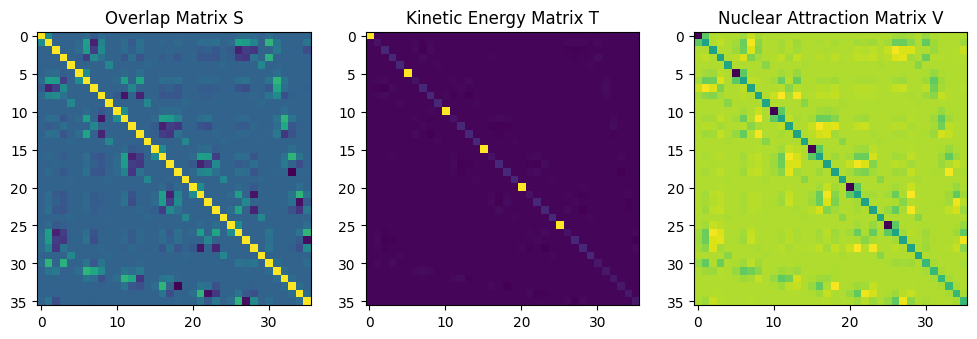

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize = (12, 6))  

axes[0].imshow(S_my, cmap = "viridis")
axes[1].imshow(T_my, cmap = "viridis")
axes[0].set_title("Overlap Matrix S")
axes[1].set_title("Kinetic Energy Matrix T")
axes[2].imshow(V_my, cmap = "viridis")
axes[2].set_title("Nuclear Attraction Matrix V")


In [10]:
import pyscf
from pyscf import gto

mol_pyscf = gto.M(
    atom=[(atom.symbol, tuple(atom.coord)) for atom in benzene.atoms],
    basis="sto-3g",
    unit="Angstrom",
)
S_pyscf = mol_pyscf.intor("int1e_ovlp")
T_pyscf = mol_pyscf.intor("int1e_kin")
V_pyscf = mol_pyscf.intor("int1e_nuc")

Text(0.5, 1.0, 'Nuclear Attraction Matrix V (PySCF)')

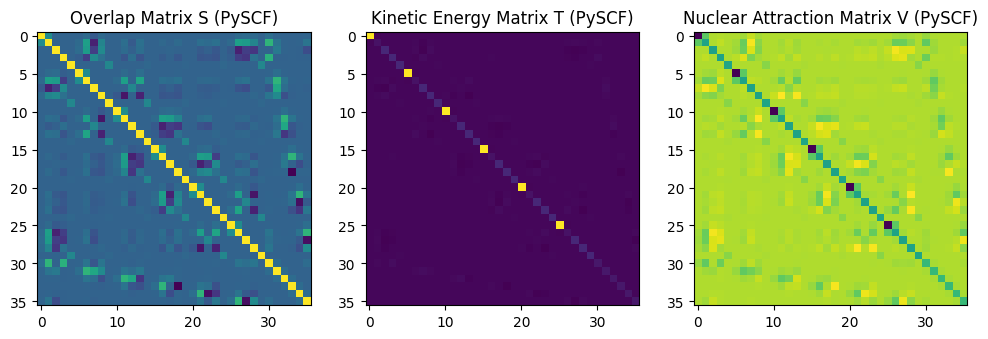

In [11]:
fig, axes = plt.subplots(1, 3, figsize = (12, 6))   

axes[0].imshow(S_pyscf, cmap = "viridis")
axes[1].imshow(T_pyscf, cmap = "viridis")
axes[0].set_title("Overlap Matrix S (PySCF)")
axes[1].set_title("Kinetic Energy Matrix T (PySCF)")
axes[2].imshow(V_pyscf, cmap = "viridis")
axes[2].set_title("Nuclear Attraction Matrix V (PySCF)")


In [13]:
from pyscf import gto

molints = MolecularIntegrals(benzene, sto3g)
mol_pyscf = gto.M(
    atom=[(atom.symbol, tuple(atom.coord)) for atom in benzene.atoms],
    basis="sto-3g",
    unit="Angstrom",
)


%timeit molints.overlap_matrix()
%timeit mol_pyscf.intor("int1e_ovlp")

%timeit molints.kinetic_matrix()
%timeit mol_pyscf.intor("int1e_kin")

%timeit molints.nuclear_attraction_matrix()
%timeit mol_pyscf.intor("int1e_nuc")

135 μs ± 474 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
151 μs ± 1.29 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
167 μs ± 448 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
309 μs ± 653 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
6.21 ms ± 3.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.47 ms ± 5.14 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [15]:
np.allclose(S_my, S_pyscf)


True

In [16]:
np.allclose(T_my, T_pyscf)


True

In [17]:
np.allclose(V_my, V_pyscf)

True